# LUIS MIGUEL GIRALDO HURTADO

# Análisis predictivo de datos - Evaluación 1

**Condiciones de entrega de la evaluación:**

- Debe entregar un archivo en formato .ipynb.
- El código debe correr correctamente cuando las celdas se ejecutan de manera secuencial.
- Debe entregar el código ya ejecutado.
- Elimine previamente todo el código que sea basura, solo entregue el código que de respuesta a lo que se le pide que haga.

Con el archivo de datos suministrado, va a crear un modelo de aprendizaje de máquina que prediga la variable **Weight**. Para escoger el modelo a utilizar se debe tener en cuenta que esta variable es **numérica** o **cuantitativa**.

Información sobre este archivo, incluido el diccionario de datos, la puede obtener en [Kaggle](https://www.kaggle.com/datasets/samruddhim/olympics-althlete-events-analysis).

## Carga y análisis exploratorio

Reporte los hallazgos en un celda de texto.

Cargue el archivo de datos, haga un breve análisis exploratorio y descarte las variables con alguna de estas condiciones:

- son claves primarias,
- tienen valores únicos,
- son redundantes con respecto a otras variables del dataset, o
- representan un riesgo de filtración de datos.

Gestione los datos duplicados y los datos nulos. En el caso de la variable **Medal**, impute a los datos nulos el valor **No medal**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('athlete_events.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


In [2]:
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,271116.0,68248.954396,39022.286345,1.0,34643.0,68205.0,102097.25,135571.0
Age,261642.0,25.556898,6.393561,10.0,21.0,24.0,28.00,97.0
Height,210945.0,175.338970,10.518462,127.0,168.0,175.0,183.00,226.0
Weight,208241.0,70.702393,14.348020,25.0,60.0,70.0,79.00,214.0
Year,271116.0,1978.378480,29.877632,1896.0,1960.0,1988.0,2002.00,2016.0


In [4]:
df.describe(include='object').T

,count,unique,top,freq
Name,271116,134732,Robert Tait McKenzie,58
Sex,271116,2,M,196594
Team,271116,1184,United States,17847
NOC,271116,230,USA,18853
Games,271116,51,2000 Summer,13821
Season,271116,2,Summer,222552
City,271116,42,London,22426
Sport,271116,66,Athletics,38624
Event,271116,765,Football Men's Football,5733
Medal,39783,3,Gold,13372


In [5]:
unicos = []
for col in df.columns:
    unicos.append(len(df[col].unique()))

resumen = pd.DataFrame({
    'tipo': df.dtypes,
    'unicos': unicos,
    'nulos': df.isnull().sum(),
    'pct_nulos': (df.isnull().sum() * 100 / df.shape[0]).round(2)
    })

print('Filas:', df.shape[0], ' Columnas:', df.shape[1])
print('Registros duplicados:', df.duplicated().sum())
resumen

Filas: 271116  Columnas: 15
Registros duplicados: 1385


,tipo,unicos,nulos,pct_nulos
ID,int64,135571,0,0.00
Name,object,134732,0,0.00
Sex,object,2,0,0.00
Age,float64,75,9474,3.49
Height,float64,96,60171,22.19
Weight,float64,221,62875,23.19
Team,object,1184,0,0.00
NOC,object,230,0,0.00
Games,object,51,0,0.00
Year,int64,35,0,0.00


### Criterio para descartar variables

Antes de quitar cualquier columna revisamos una por una las cuatro condiciones que pide el enunciado y dejamos la prueba en el notebook. La idea es no botar nada por intuición: si no hay una salida que lo respalde, la variable se queda.

| Condición | Cómo la comprobamos |
|---|---|
| Clave primaria | Contamos los valores únicos y los comparamos con el número de filas |
| Valor único | Contamos los valores únicos: si da 1, la variable no varía |
| Redundante | Mostramos que una variable se reconstruye con otras o que queda determinada por otra |
| Filtración | Revisamos si la variable existe antes de predecir o si sale del valor que queremos predecir |

Prueba 1: claves primarias y variables que no varían.

In [6]:
for col in df.columns:
    n = len(df[col].unique())
    print(f'{col:8s} unicos = {n:6d}   clave_primaria = {n == df.shape[0]}   no_varia = {n == 1}')

ID       unicos = 135571   clave_primaria = False   no_varia = False
Name     unicos = 134732   clave_primaria = False   no_varia = False
Sex      unicos =      2   clave_primaria = False   no_varia = False
Age      unicos =     75   clave_primaria = False   no_varia = False
Height   unicos =     96   clave_primaria = False   no_varia = False
Weight   unicos =    221   clave_primaria = False   no_varia = False
Team     unicos =   1184   clave_primaria = False   no_varia = False
NOC      unicos =    230   clave_primaria = False   no_varia = False
Games    unicos =     51   clave_primaria = False   no_varia = False
Year     unicos =     35   clave_primaria = False   no_varia = False
Season   unicos =      2   clave_primaria = False   no_varia = False


City     unicos =     42   clave_primaria = False   no_varia = False
Sport    unicos =     66   clave_primaria = False   no_varia = False
Event    unicos =    765   clave_primaria = False   no_varia = False
Medal    unicos =      4   clave_primaria = False   no_varia = False


Ninguna columna es clave primaria ni constante, así que por ese lado no se descarta nada. Pero ID y Name sí son identificadores del atleta y se repiten porque cada persona compite en varios eventos. Para confirmar que dicen lo mismo contamos las combinaciones distintas de las dos: si hay tantas combinaciones como ID, es porque cada ID tiene un solo nombre.

In [7]:
print('ID distintos:', len(df['ID'].unique()))
print('Combinaciones distintas de ID y Name:', len(df[['ID', 'Name']].drop_duplicates()))

ID distintos: 135571
Combinaciones distintas de ID y Name: 135571


Prueba 2: redundancia. Aquí usamos el mismo truco de contar combinaciones. Si al cruzar dos variables salen tantas combinaciones como categorías tiene la primera, entonces la primera determina a la segunda y una de las dos sobra.

In [8]:
reconstruido = df['Year'].astype(str) + ' ' + df['Season']
print('Games se reconstruye con Year y Season en el', round((reconstruido == df['Games']).mean() * 100, 1), '% de las filas')

print('Event distintos:', len(df['Event'].unique()), ' combinaciones de Event y Sport:', len(df[['Event', 'Sport']].drop_duplicates()))

print('Games distintos:', len(df['Games'].unique()), ' combinaciones de Games y City:', len(df[['Games', 'City']].drop_duplicates()))

print('NOC distintos:', len(df['NOC'].unique()), ' combinaciones de NOC y Team:', len(df[['NOC', 'Team']].drop_duplicates()))
print('Valores de Team para NOC = CHN:', df.loc[df['NOC'] == 'CHN', 'Team'].unique())

Games se reconstruye con Year y Season en el

 100.0 % de las filas
Event distintos: 765  combinaciones de Event y Sport: 765


Games distintos: 51  combinaciones de Games y City: 52


NOC distintos: 230  combinaciones de NOC y Team: 1231
Valores de Team para NOC = CHN: ['China' 'China-2' 'China-1' 'China-3']


Prueba 3: filtración. Weight es una característica física del atleta y no el resultado de algo que pase después, así que ninguna variable puede salir de ella. La única que nos hizo dudar fue Event, porque en boxeo, lucha, judo y halterofilia la categoría en la que compite el atleta se define según su peso.

In [9]:
deportes_peso = (df['Sport'] == 'Boxing') | (df['Sport'] == 'Weightlifting') | (df['Sport'] == 'Wrestling') | (df['Sport'] == 'Judo') | (df['Sport'] == 'Taekwondo')
print('Registros en deportes que compiten por categoria de peso:', df[deportes_peso].shape[0])

df[df['Sport'] == 'Weightlifting'].groupby('Event')['Weight'].describe().round(1).head(6)

Registros en deportes que compiten por categoria de peso: 21545


,count,mean,std,min,25%,50%,75%,max
Event,,,,,,,,
Weightlifting Men's All-Around Dumbbell Contest,2.0,90.0,21.2,75.0,82.5,90.0,97.5,105.0
Weightlifting Men's Bantamweight,368.0,56.3,2.1,50.0,56.0,56.0,56.0,69.0
Weightlifting Men's Featherweight,446.0,60.9,2.9,52.0,59.5,60.0,62.0,77.0
Weightlifting Men's Flyweight,141.0,53.2,2.2,50.0,52.0,52.0,54.0,67.0
Weightlifting Men's Heavyweight,285.0,108.5,12.8,83.0,102.5,105.0,110.0,163.0
Weightlifting Men's Heavyweight I,107.0,99.4,4.4,90.0,98.0,100.0,100.0,125.0


### Variables descartadas

| Variable | Condición | Evidencia |
|---|---|---|
| ID | Redundante | 135.571 ID y 135.571 combinaciones de ID y Name: las dos identifican al mismo atleta |
| Name | Identificador sin valor predictivo | 134.732 nombres distintos, y un nombre no dice nada sobre el peso |
| Games | Redundante | Se reconstruye con Year y Season en el 100% de las filas |
| City | Redundante | 51 ediciones y 52 combinaciones de Games y City: solo una edición tuvo dos sedes, así que la ciudad la fija el año |
| Team | Redundante | Es el mismo país que NOC pero con 1.184 categorías en vez de 230, por variantes como China-1 y China-2 |
| Event | Redundante y con riesgo de filtración | 765 Event y 765 combinaciones de Event y Sport: cada Event tiene un solo Sport, así que Event es Sport separado por sexo y modalidad. Además 21.545 registros son de deportes que compiten por categoría de peso |

La que más nos costó decidir fue Event, y la descartamos por dos razones. La primera, que es la que aplica a todas las filas, es que su contenido ya está repartido entre Sport y Sex y sus 765 categorías solo agregan detalle. La segunda es el riesgo de filtración: en los eventos por categoría de peso la variable no ayuda a predecir el peso, prácticamente lo está diciendo. En la tabla de halterofilia se ve claro, porque en Weightlifting Men's Bantamweight el peso promedio es 56,3 kg con una desviación de apenas 2,1 kg. Un modelo con esa variable se vería mucho mejor sin haber aprendido nada.

In [10]:
df = df.drop_duplicates().reset_index(drop=True)
print('Filas despues de eliminar duplicados:', df.shape[0])

df['Medal'] = df['Medal'].fillna('No medal')

df = df.drop(columns=['ID', 'Name', 'Games', 'City', 'Team', 'Event'])

print('Columnas conservadas:', list(df.columns))
print()
print('Nulos:')
print(df.isnull().sum())

Filas despues de eliminar duplicados: 269731


Columnas conservadas: ['Sex', 'Age', 'Height', 'Weight', 'NOC', 'Year', 'Season', 'Sport', 'Medal']

Nulos:
Sex           0
Age        9315
Height    58814
Weight    61527
NOC           0
Year          0
Season        0
Sport         0
Medal         0
dtype: int64


Los duplicados los buscamos sobre el registro completo, antes de quitar columnas. Si lo hiciéramos después, dos atletas distintos que coincidan en sexo, edad, estatura, peso, país, año y deporte quedarían marcados como repetidos y perderíamos filas que sí son válidas.

De los nulos que quedan, el de Weight es el caso serio porque es la variable objetivo. Imputarlo sería inventarle al modelo la respuesta que tiene que aprender, así que esas filas se eliminan. Height y Age faltan casi en los mismos registros, de manera que al quitar los nulos del objetivo se pierde muy poco más.

In [11]:
sin_weight = df.dropna(subset=['Weight'])
print('Nulos que quedan al eliminar las filas sin Weight:')
print(sin_weight.isnull().sum())
print()

df = df.dropna().reset_index(drop=True)

print()
print('Dataset final:', df.shape)
df.info()

Nulos que quedan al eliminar las filas sin Weight:
Sex          0
Age        862
Height    1364
Weight       0
NOC          0
Year         0
Season       0
Sport        0
Medal        0
dtype: int64


Dataset final: (206152, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206152 entries, 0 to 206151
Data columns (total 9 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Sex     206152 non-null  object 
 1   Age     206152 non-null  float64
 2   Height  206152 non-null  float64
 3   Weight  206152 non-null  float64
 4   NOC     206152 non-null  object 
 5   Year    206152 non-null  int64  
 6   Season  206152 non-null  object 
 7   Sport   206152 non-null  object 
 8   Medal   206152 non-null  object 
dtypes: float64(3), int64(1), object(5)
memory usage: 14.2+ MB


### Hallazgos del análisis exploratorio

El archivo tiene 271.116 filas y 15 columnas, con 1.385 registros duplicados. Lo primero que hay que entender es que cada fila es la participación de un atleta en un evento y no un atleta: por eso ID se repite y hay 135.571 personas distintas en 271.116 filas.

Ninguna variable es clave primaria ni constante, así que esas dos condiciones del enunciado no descartan nada. Lo que sí encontramos fue bastante redundancia, porque el dataset guarda la misma información varias veces con distinto nivel de detalle. Games es Year más Season, la ciudad la fija el año, Team es NOC con más ruido y Event es Sport separado por sexo y modalidad. En cada pareja nos quedamos con la versión más simple y limpia. Riesgo de filtración encontramos solo en Event, por lo de las categorías de peso.

Los nulos tampoco están repartidos al azar. Se concentran en Medal (85,3%), Weight (23,2%), Height (22,2%) y Age (3,5%). El de Medal ni siquiera es un dato perdido: significa que el atleta no ganó medalla, y por eso el enunciado pide imputarlo con No medal. Los de Weight, Height y Age son casi las mismas filas, participaciones antiguas a las que no les tomaron talla ni peso, y se eliminan porque falta la variable objetivo.

El dataset nos queda en 206.152 filas y 9 columnas: Sex, Age, Height, Weight, NOC, Year, Season, Sport y Medal.

Haga un análisis de las variables categóricas no descartadas, e identifique:

- Variables nominales.
- Variables ordinales.
- Variables con alta cardinalidad.
- Variables con categorías atípicas.

Indique qué tipo de procesamiento debería recibir cada una de las variables, de acuerdo con los resultados del análisis anterior.

Reporte los resultados del análisis en una celda de texto.

In [12]:
cat_vars = df.select_dtypes(include='object').columns.to_list()
print('Variables categoricas:', cat_vars)

df[cat_vars].describe().T

Variables categoricas: ['Sex', 'NOC', 'Season', 'Sport', 'Medal']


,count,unique,top,freq
Sex,206152,2,M,139441
NOC,206152,226,USA,14207
Season,206152,2,Summer,166693
Sport,206152,56,Athletics,32374
Medal,206152,4,No medal,175971


In [13]:
for var in cat_vars:
    print(f'El conteo de la variable {var} es: \n {df[var].value_counts()} \n')

El conteo de la variable Sex es: 
 Sex
M    139441
F     66711
Name: count, dtype: int64 

El conteo de la variable NOC es: 
 NOC
USA    14207
FRA     7975
CAN     7965
GBR     7765
ITA     7697
       ...  
SAA        3
SSD        3
YMD        2
UAR        1
NFL        1
Name: count, Length: 226, dtype: int64 

El conteo de la variable Season es: 
 Season
Summer    166693
Winter     39459
Name: count, dtype: int64 

El conteo de la variable Sport es: 
 Sport
Athletics                    32374
Swimming                     18776
Gymnastics                   18271
Rowing                        7790
Cycling                       7774
Cross Country Skiing          7529
Shooting                      7260
Fencing                       6537
Alpine Skiing                 6322
Canoeing                      5550
Wrestling                     5186
Sailing                       4863
Biathlon                      4615
Ice Hockey                    4579
Equestrianism                 4553
Football   

Para las categorías atípicas contamos cuántas tienen tan pocos registros que el modelo no alcanza a aprender nada de ellas.

In [14]:
for var in cat_vars:
    conteo = df[var].value_counts()
    raras = conteo[conteo < 100]
    print(f'{var:7s} categorias = {len(conteo):4d}   con menos de 100 registros = {len(raras):4d}   filas = {raras.sum():5d}')

Sex     categorias =    2   con menos de 100 registros =    0   filas =     0
NOC     categorias =  226   con menos de 100 registros =   99   filas =  4221
Season  categorias =    2   con menos de 100 registros =    0   filas =     0
Sport   categorias =   56   con menos de 100 registros =    5   filas =    69
Medal   categorias =    4   con menos de 100 registros =    0   filas =     0


### Resultado del análisis de las variables categóricas

| Variable | Categorías | Tipo | Cardinalidad | Categorías atípicas | Procesamiento |
|---|---|---|---|---|---|
| Sex | 2 | Nominal binaria | Baja | No | OneHotEncoder con drop='if_binary' |
| Season | 2 | Nominal binaria | Baja | No | OneHotEncoder con drop='if_binary' |
| Medal | 4 | Ordinal | Baja | No | OrdinalEncoder declarando el orden |
| Sport | 56 | Nominal | Media | Sí, 5 deportes con menos de 100 registros | OneHotEncoder con min_frequency |
| NOC | 226 | Nominal | Alta | Sí, 99 países con menos de 100 registros | TargetEncoder |

La única variable con orden real es Medal, y solo después de la imputación que pide el enunciado: No medal, Bronze, Silver, Gold. El orden toca declararlo a mano, porque si lo dejamos alfabético queda Bronze, Gold, No medal, Silver y el modelo aprendería una jerarquía que no existe. Vale la pena aclarar que No medal no es un "no aplica" disfrazado: es el nivel más bajo de la escala, porque no ganar está por debajo de ganar bronce.

Las demás son nominales. Sex y Season las codificamos con drop='if_binary' para que salga una sola columna en vez de dos que dicen exactamente lo mismo.

Con la cardinalidad tenemos dos casos distintos. NOC tiene 226 categorías, y codificarla con One-Hot crearía 226 columnas casi vacías, 99 de ellas estimadas con menos de 100 atletas; por eso usamos TargetEncoder, que la deja en una sola columna. Sport, con 56, está en un punto intermedio: la codificamos con One-Hot pero poniendo min_frequency, para que los deportes con muy pocos registros, como Motorboating con 1 fila y Lacrosse con 2, se junten en una sola categoría en lugar de generar columnas que el modelo no puede aprender.

Sobre las categorías atípicas, no encontramos errores de escritura ni categorías raras. Son atípicas porque tienen pocos registros, no porque estén mal, y por eso las agrupamos en vez de corregirlas o borrarlas.

Haga un análisis de las variables cuantitativas no descartadas, e identifique:

- Variables que son aproximadamente normales.
- Variables con datos atípicos.

Indique qué tipo de procesamiento debería recibir cada una de las variables, según su distribución y la presencia de valores atípicos.

Reporte los resultados del análisis en una celda de texto.

Antes de analizar hay que separar lo numérico de lo cuantitativo. Year es numérica pero es un año: tiene 35 valores y no tiene sentido preguntarse si es normal o si tiene atípicos, porque sus valores extremos son simplemente las primeras olimpiadas. La miramos aparte.

In [15]:
num_vars = df.select_dtypes(include='number').columns.to_list()

for var in num_vars:
    print(f'{var:7s} valores unicos = {len(df[var].unique()):4d}   min = {df[var].min():7.1f}   max = {df[var].max():7.1f}')

Age     valores unicos =   61   min =    11.0   max =    71.0
Height  valores unicos =   94   min =   127.0   max =   226.0
Weight  valores unicos =  217   min =    25.0   max =   214.0
Year    valores unicos =   35   min =  1896.0   max =  2016.0


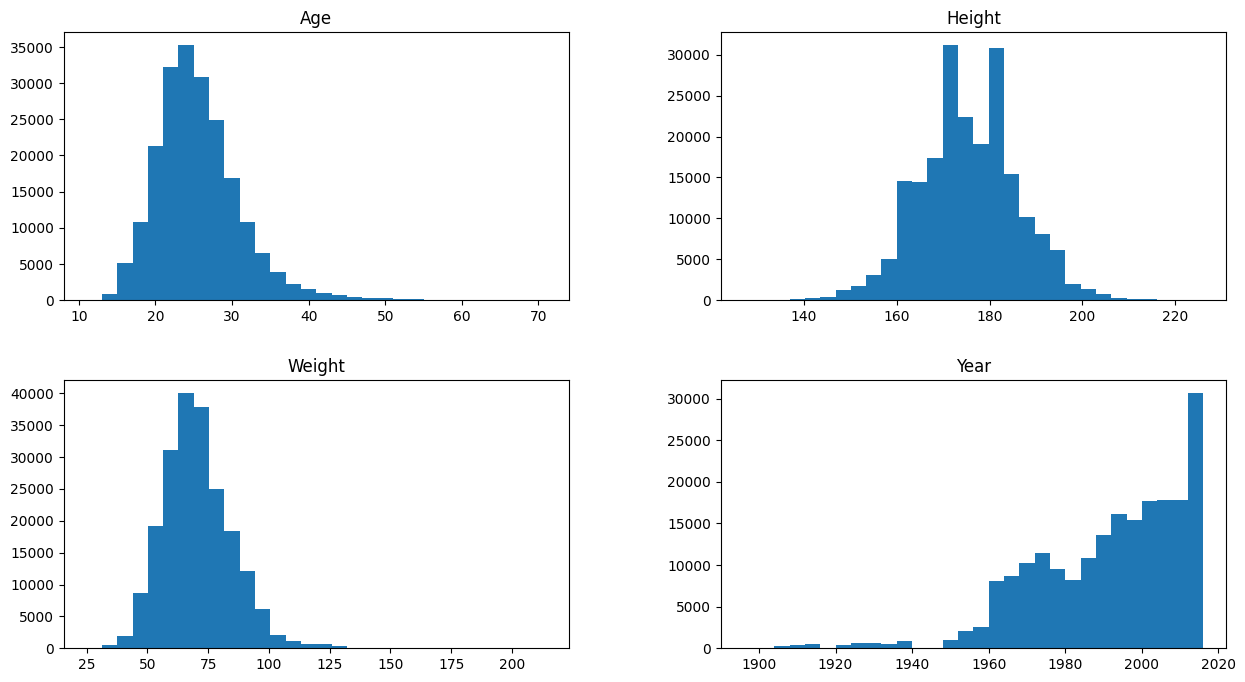

In [16]:
cuant_vars = ['Age', 'Height', 'Weight']

df[num_vars].hist(bins=30, figsize=(15, 8), layout=(2, 2), grid=False);

El histograma da una idea, pero la que decide es la prueba. Usamos Kolmogorov-Smirnov y la acompañamos con la asimetría y la curtosis, porque con 206.152 registros la prueba rechaza la normalidad por diferencias mínimas y por sí sola no distingue una variable simétrica de una muy sesgada.

In [17]:
from scipy.stats import kstest

for var in cuant_vars:
    __, p_value = kstest(df[var], 'norm', args=(df[var].mean(), df[var].std()))
    print(f'Prueba de Kolmogorov-Smirnov para {var}:')
    print(f'  Valor p: {p_value:.3e}')
    if p_value > 0.05:
        print(f'  {var} parece ser normal (no se rechaza la hipotesis nula)')
    else:
        print(f'  {var} no parece ser normal (se rechaza la hipotesis nula)')
    print(f'  Asimetria: {df[var].skew():.3f}   Curtosis: {df[var].kurt():.3f}')
    print()

Prueba de Kolmogorov-Smirnov para Age:
  Valor p: 0.000e+00
  Age no parece ser normal (se rechaza la hipotesis nula)
  Asimetria: 1.138   Curtosis: 3.124

Prueba de Kolmogorov-Smirnov para Height:
  Valor p: 7.976e-209
  Height no parece ser normal (se rechaza la hipotesis nula)
  Asimetria: 0.017   Curtosis: 0.163

Prueba de Kolmogorov-Smirnov para Weight:
  Valor p: 0.000e+00
  Weight no parece ser normal (se rechaza la hipotesis nula)
  Asimetria: 0.792   Curtosis: 2.008



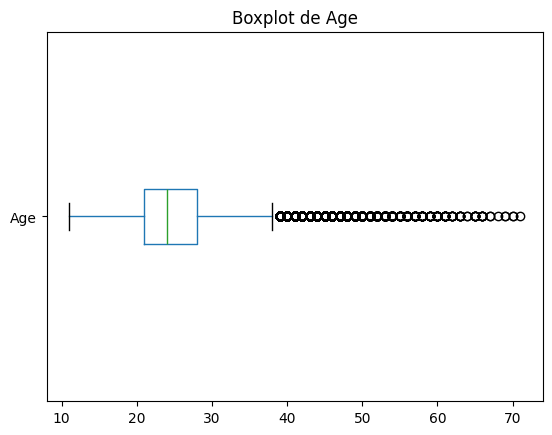

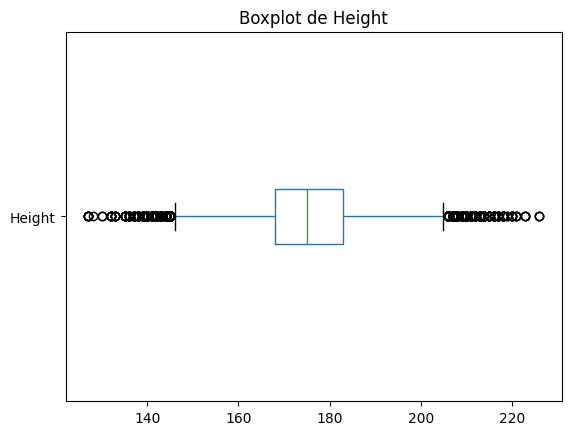

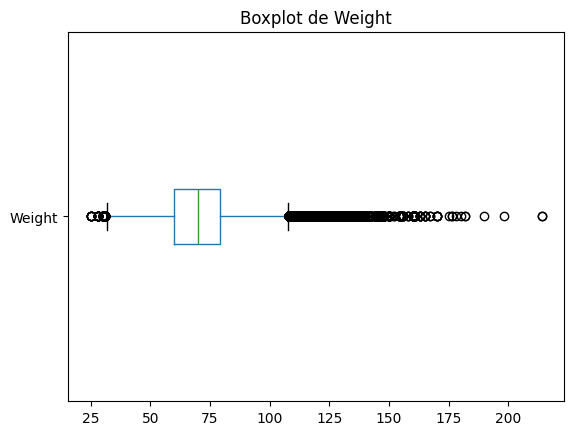

In [18]:
for var in cuant_vars:
    plt.figure()
    df.boxplot(column=var, grid=False, vert=False)
    plt.title(f'Boxplot de {var}')
    plt.show()

No es suficiente con decir que hay atípicos. Los contamos y decimos entre qué límites se consideran normales, usando el rango intercuartil.

In [19]:
for var in cuant_vars:
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    atipicos = ((df[var] < lower_limit) | (df[var] > upper_limit)).sum()
    print(f'{var:7s} limites = [{lower_limit:6.1f}, {upper_limit:6.1f}]   atipicos = {atipicos:5d} ({atipicos / df.shape[0] * 100:.2f}%)   rango real = [{df[var].min():.1f}, {df[var].max():.1f}]')

Age     limites = [  10.5,   38.5]   atipicos =  4626 (2.24%)   rango real = [11.0, 71.0]
Height  limites = [ 145.5,  205.5]   atipicos =  1310 (0.64%)   rango real = [127.0, 226.0]
Weight  limites = [  31.5,  107.5]   atipicos =  3174 (1.54%)   rango real = [25.0, 214.0]


### Elección de la transformación de cada variable

La transformación no la escogimos por costumbre sino comparando cada variable original con la escalada y la transformada. Dejamos las tres gráficas, no solo la transformada, y miramos la asimetría y la curtosis para no decidir a ojo.

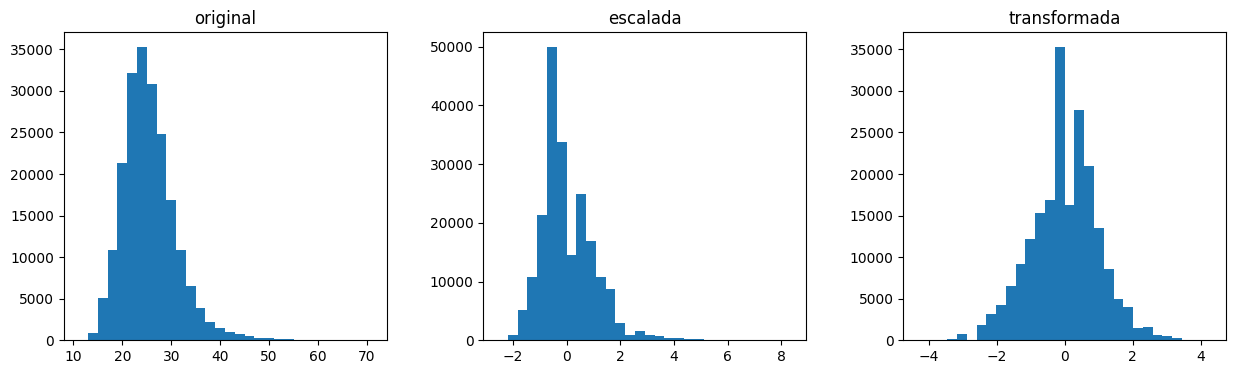

In [20]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PowerTransformer

comparacion_age = pd.DataFrame({
    'original': df['Age'],
    'escalada': StandardScaler().fit_transform(df[['Age']]).ravel(),
    'transformada': PowerTransformer().fit_transform(df[['Age']]).ravel()
    })

comparacion_age.hist(bins=30, figsize=(15, 4), layout=(1, 3), grid=False);

In [21]:
print('Age')
print(comparacion_age.skew().round(3))
print(comparacion_age.kurt().round(3))

Age
original        1.138
escalada        1.138
transformada   -0.010
dtype: float64
original        3.124
escalada        3.124
transformada    0.374
dtype: float64


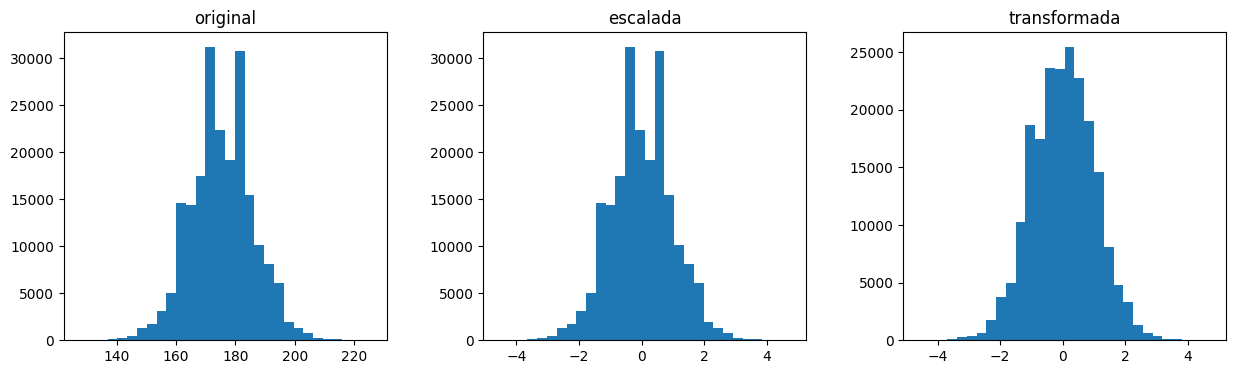

In [22]:
comparacion_height = pd.DataFrame({
    'original': df['Height'],
    'escalada': StandardScaler().fit_transform(df[['Height']]).ravel(),
    'transformada': PowerTransformer().fit_transform(df[['Height']]).ravel()
    })

comparacion_height.hist(bins=30, figsize=(15, 4), layout=(1, 3), grid=False);

In [23]:
print('Height')
print(comparacion_height.skew().round(3))
print(comparacion_height.kurt().round(3))

Height
original        0.017
escalada        0.017
transformada    0.003
dtype: float64
original        0.163
escalada        0.163
transformada    0.164
dtype: float64


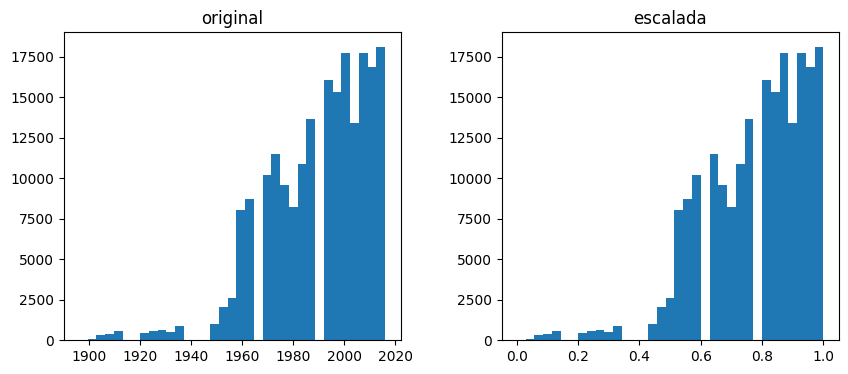

In [24]:
comparacion_year = pd.DataFrame({
    'original': df['Year'],
    'escalada': MinMaxScaler().fit_transform(df[['Year']]).ravel()
    })

comparacion_year.hist(bins=35, figsize=(10, 4), layout=(1, 2), grid=False);

### Resultado del análisis de las variables cuantitativas

Las cuantitativas de verdad son Age, Height y Weight, que es el objetivo. Year es numérica pero no cuantitativa, como ya explicamos.

Sobre la normalidad, la prueba de Kolmogorov-Smirnov la rechaza en las tres, pero con este tamaño de muestra eso era de esperarse y no nos sirve para diferenciarlas. La asimetría y la curtosis sí:

| Variable | Asimetría | Curtosis | Lectura |
|---|---|---|---|
| Height | 0,017 | 0,163 | Simétrica y con colas normales, es la única aproximadamente normal |
| Weight | 0,792 | 2,008 | Sesgada a la derecha, pero es el objetivo y no se transforma |
| Age | 1,138 | 3,124 | Claramente sesgada a la derecha |

Los atípicos quedaron así:

| Variable | Límites | Atípicos | Qué son |
|---|---|---|---|
| Age | [10,5 , 38,5] | 4.626 (2,24%) | Atletas mayores, hasta 71 años |
| Height | [145,5 , 205,5] | 1.310 (0,64%) | Gimnastas y basquetbolistas |
| Weight | [31,5 , 107,5] | 3.174 (1,54%) | Halterófilos y lanzadores |

Son atípicos reales y no errores de captura: un atleta de 226 cm existe. Decidimos no eliminarlos porque al hacerlo borraríamos justamente los deportes que más separan el peso, que son los que más le sirven al modelo.

En cuanto al procesamiento, la idea es no aplicarle el mismo escalador a todo sino el que corresponde a la forma que medimos en cada variable.

Height va con StandardScaler. Como ya es simétrica solo hay que centrarla y escalarla. La comparación confirma que PowerTransformer no aporta nada, porque la asimetría pasa de 0,017 a 0,003 y la curtosis queda igual, así que usarlo sería complicar el flujo sin ganar precisión.

Age va con PowerTransformer, que es el caso contrario. La transformación de potencia le corrige el sesgo casi por completo: la asimetría pasa de 1,138 a -0,010 y la curtosis de 3,124 a 0,374. En la gráfica del medio se ve que un escalador simple no le habría cambiado la forma, queda idéntica a la original.

Year va con MinMaxScaler. Está acotada entre 1896 y 2016 y no tiene atípicos, así que basta con llevarla al rango [0, 1]. La gráfica muestra que la forma no cambia, solo la escala.

Weight no lleva transformación porque es la variable objetivo.

Haga análisis bivariados entre las variables de su dataset y la variable objetivo, e identifique que variables serían potencialmente buenas predictoras y cuales no.

Reporte sus resultados en una celda de texto.

In [25]:
df[num_vars].corr().round(3)

,Age,Height,Weight,Year
Age,1.000,0.142,0.212,0.090
Height,0.142,1.000,0.797,0.048
Weight,0.212,0.797,1.000,0.022
Year,0.090,0.048,0.022,1.000


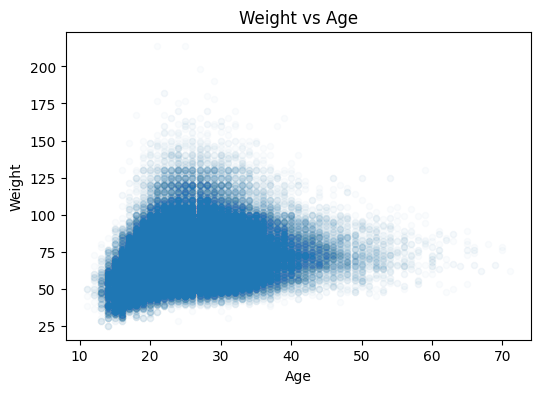

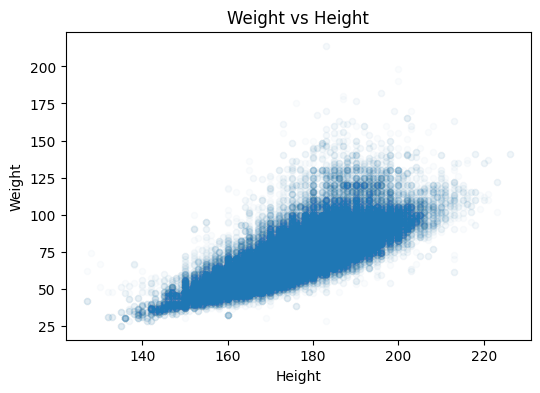

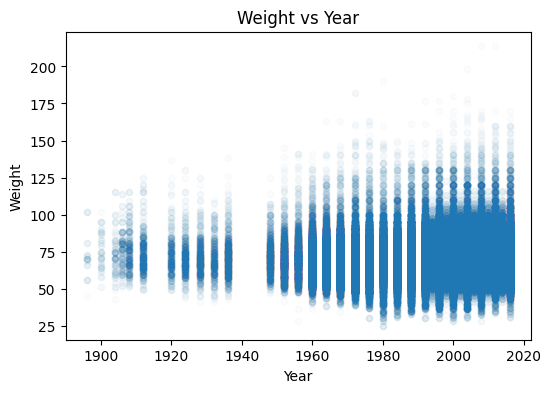

In [26]:
for var in ['Age', 'Height', 'Year']:
    df.plot(kind='scatter', x=var, y='Weight', alpha=0.02, figsize=(6, 4), title=f'Weight vs {var}')
    plt.show()

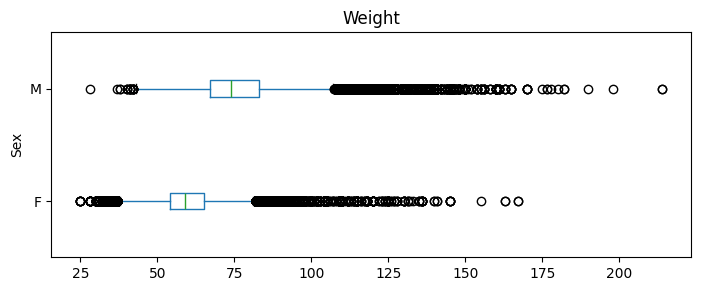

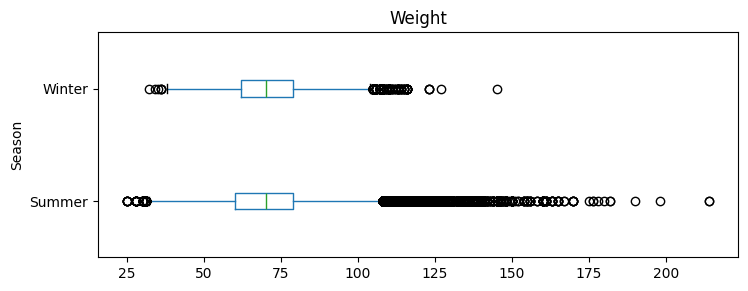

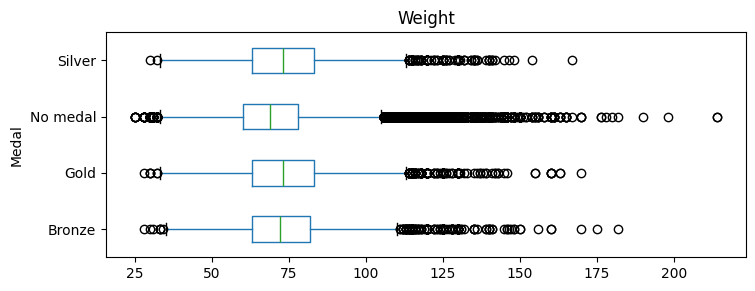

In [27]:
for var in ['Sex', 'Season', 'Medal']:
    df.boxplot(column='Weight', by=var, grid=False, vert=False, figsize=(8, 3))
    plt.suptitle('')
    plt.show()

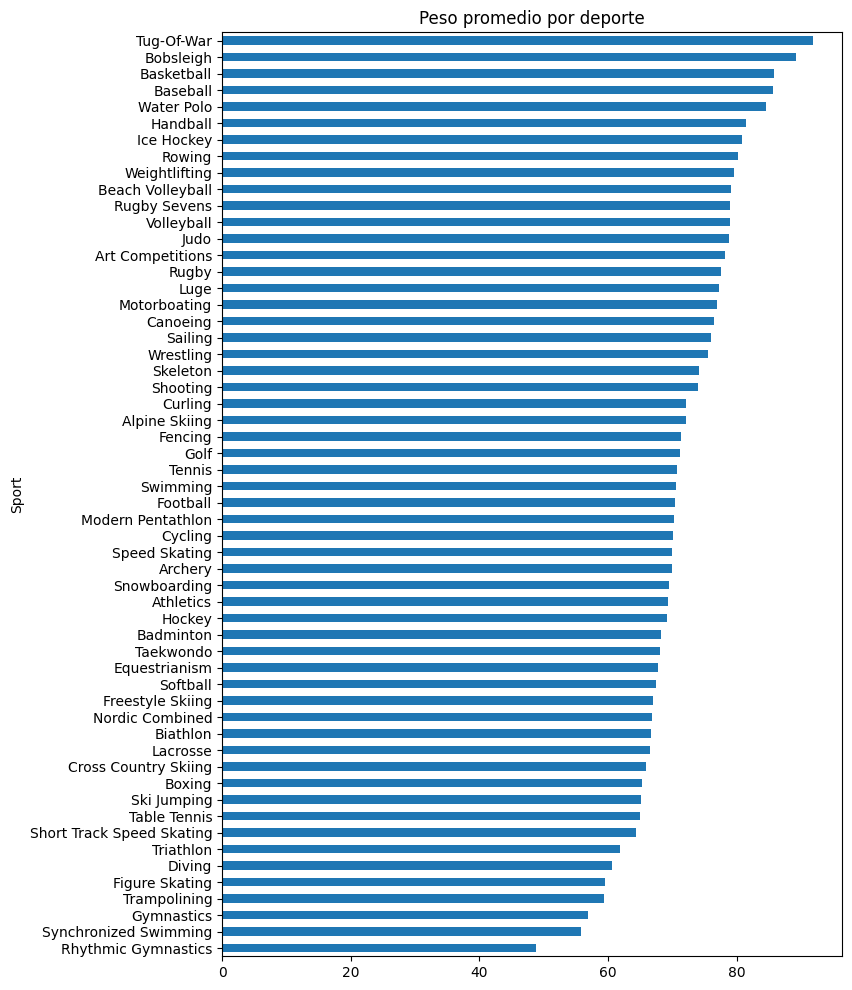

In [28]:
df.groupby('Sport')['Weight'].mean().sort_values().plot(kind='barh', figsize=(8, 12), title='Peso promedio por deporte');

Para poder comparar todas las variables con la misma medida usamos el rango de los promedios, o sea cuánto se separa el peso promedio entre las categorías de cada variable. Entre más amplio, mejor predictora. Lo calculamos sobre las categorías con al menos 100 registros, porque una categoría con un solo atleta agranda el rango sin aportar información.

In [29]:
for var in cat_vars + ['Year']:
    grupos = df.groupby(var)['Weight'].describe()
    grupos = grupos[grupos['count'] >= 100]
    rango = grupos['mean'].max() - grupos['mean'].min()
    print(f'{var:7s} rango de los promedios = {rango:6.2f} kg')

print()
print('Desviacion estandar de Weight:', round(df['Weight'].std(), 2), 'kg')

Sex     rango de los promedios =  15.77 kg
NOC     rango de los promedios =  26.19 kg
Season  rango de los promedios =   0.08 kg
Sport   rango de los promedios =  40.40 kg
Medal   rango de los promedios =   3.97 kg


Year    rango de los promedios =   6.47 kg

Desviacion estandar de Weight: 14.34 kg


### Resultado del análisis bivariado

La desviación estándar de Weight es 14,34 kg. Ese es el error que tendría un modelo que siempre predijera el promedio, así que contra eso comparamos cada variable.

| Variable | Medida | Valor | Lectura |
|---|---|---|---|
| Height | Correlación | 0,797 | La mejor predictora, muy por encima del resto |
| Sport | Rango de promedios | 40,40 kg | Muy buena, va de gimnasia rítmica (48,8 kg) a bobsleigh (89,2 kg) |
| NOC | Rango de promedios | 26,19 kg | Buena |
| Sex | Rango de promedios | 15,77 kg | Muy buena, 60,0 kg contra 75,8 kg |
| Year | Rango de promedios | 6,47 kg | Débil |
| Medal | Rango de promedios | 3,97 kg | Muy débil |
| Season | Rango de promedios | 0,08 kg | No sirve |
| Age | Correlación | 0,212 | Débil, pero aporta información distinta |

Las mejores predictoras son Height, Sport y Sex. Que la estatura salga casi determinante tiene todo el sentido, porque el peso y la talla están midiendo el mismo tamaño del cuerpo. Lo interesante es que el deporte y el sexo no repiten a la estatura sino que aportan algo distinto: separan atletas que miden lo mismo pero tienen contexturas diferentes, porque un gimnasta y un nadador de 175 cm no pesan igual.

NOC también separa bastante, 26 kg, aunque sale cara porque tiene 226 categorías y necesita un codificador especial.

Age nos pareció el caso más interesante. Su correlación es baja, 0,212, pero está poco relacionada con la estatura (0,142), así que la información que trae es nueva. Preferimos una variable débil que aporta algo distinto antes que una fuerte que repita lo que ya tenemos, porque meter dos variables que dicen lo mismo no aporta el doble.

Las que no sirven son Season, Medal y Year. Season no separa nada, 0,08 kg, y creemos que es porque lo que de verdad influye es el deporte y Sport ya lo recoge. Medal separa 4 kg, o sea que los medallistas pesan un poco más, pero es muy poco frente a los 14,34 kg de desviación. Year separa 6,47 kg y casi todo se debe a las primeras olimpiadas.

## Procesamiento de las características y entrenamiento del modelo

Cree el matriz de características $X$ con todos las variables no descartadas de su dataframe, menos la variable **Weight**, que será su variable objetivo $y$.

Particione los datos en subconjuntos de entrenamiento y prueba, en un relacion 80/20, usando `random_state=1`.

Para una primera versión de su modelo, seleccione 5 características a procesar que, de acuerdo con el análisis exploratorio realizado, parezcan ser buenas predictoras. Dentro de las 5 debe haber al menos una característica ordinal y dos nominales.

Empaquete las transformaciones que aplicará a estas características usando `ColumnTransformer`. Use el parámetro `remainder='drop'`para descartar las variables que no va a procesar.

Para el modelado va a usar un modelo de regresión logística. Cree un flujo de trabajo que integre el procesamiento y el modelado usando `Pipeline`.

Entrene el modelo y reporte los scores de entrenamiento y de prueba.

Reporte las características con las que **realmente** fue entrenado el modelo, es decir, las resultantes del paso de procesamiento.

Una aclaración sobre el modelo. El enunciado dice al comienzo que lo escojamos teniendo en cuenta que Weight es numérica o cuantitativa, pero en este punto pide una regresión logística, que es un modelo de clasificación. Nos quedamos con lo primero y usamos un modelo de regresión lineal, porque Weight toma 217 valores distintos entre 25 y 214 kg: una regresión logística trataría cada peso como una clase aparte y su score sería la proporción de atletas a los que se les acierta el peso al kilo exacto, que no dice nada útil sobre el problema.

Dentro de los modelos lineales usamos Ridge, que el profesor nos autorizó. Ridge es la misma regresión lineal pero con una penalización que evita que los coeficientes crezcan demasiado, lo cual viene bien porque Sport nos deja 42 columnas y varias corresponden a deportes con pocos registros.

Como es un modelo de regresión, el score que devuelve es el $R^2$. Y como el $R^2$ no está en kilogramos, lo acompañamos con el RMSE y el error absoluto mediano, que sí se pueden leer en las unidades del problema.

In [30]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Weight'])
y = df['Weight']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, train_size=0.8)

print(f'Tamaño del conjunto de entrenamiento es: {X_train.shape}')
print(f'Tamaño del conjunto de prueba es: {X_test.shape}')

Tamaño del conjunto de entrenamiento es: (164921, 8)
Tamaño del conjunto de prueba es: (41231, 8)


### Criterio de selección de las características

Las escogimos siguiendo el ranking del análisis bivariado de arriba hacia abajo, pero respetando la composición que exige el enunciado y cuidando no meter dos variables que digan lo mismo.

| Característica | Tipo | Por qué entra | Procesamiento y por qué |
|---|---|---|---|
| Height | Cuantitativa | La mejor predictora, correlación 0,797 | StandardScaler, porque ya es simétrica y solo hay que centrarla |
| Sport | Nominal | Rango de promedios de 40,40 kg | OneHotEncoder con min_frequency, porque son 56 categorías y varias tienen muy pocos registros |
| Sex | Nominal | Rango de promedios de 15,77 kg | OneHotEncoder con drop='if_binary', porque es binaria y basta una columna |
| Age | Cuantitativa | Correlación 0,212 y no repite lo de Height | PowerTransformer, porque está sesgada a la derecha |
| Medal | Ordinal | Es la única variable ordinal del dataset | OrdinalEncoder declarando el orden |

Quedan por fuera NOC, Year y Season. El caso de NOC fue el que más discutimos, porque mide más que Age (26,19 kg de rango contra una correlación de 0,212), pero solo hay cinco cupos y el enunciado exige al menos una ordinal y dos nominales, así que la composición pedida termina mandando sobre el ranking. Year y Season se quedan por fuera simplemente porque separan muy poco.

Medal entra aunque separe apenas 3,97 kg, por esa misma regla: es la única variable ordinal que tenemos y el enunciado obliga a incluir una. Ya sabemos que va a aportar poco, y lo comprobamos en los resultados.

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import Ridge

ss = StandardScaler()
pt = PowerTransformer()
ohe_bin = OneHotEncoder(sparse_output=False, drop='if_binary')
ohe_sport = OneHotEncoder(sparse_output=False, min_frequency=500, handle_unknown='ignore')
ore = OrdinalEncoder(categories=[['No medal', 'Bronze', 'Silver', 'Gold']])

preprocessor = ColumnTransformer(transformers=[
    ('ss', ss, ['Height']),
    ('pt', pt, ['Age']),
    ('ohe_bin', ohe_bin, ['Sex']),
    ('ohe_sport', ohe_sport, ['Sport']),
    ('ore', ore, ['Medal'])
    ],
    remainder='drop')

preprocessor

ColumnTransformer(transformers=[('ss', StandardScaler(), ['Height']),
                                ('pt', PowerTransformer(), ['Age']),
                                ('ohe_bin',
                                 OneHotEncoder(drop='if_binary',
                                               sparse_output=False),
                                 ['Sex']),
                                ('ohe_sport',
                                 OneHotEncoder(handle_unknown='ignore',
                                               min_frequency=500,
                                               sparse_output=False),
                                 ['Sport']),
                                ('ore',
                                 OrdinalEncoder(categories=[['No medal',
                                                             'Bronze', 'Silver',
                                                             'Gold']]),
                                 ['Medal'])])

In [32]:
reg = Ridge()

model = Pipeline([
    ('preprocessor', preprocessor),
    ('reg', reg)
    ])

model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ss', StandardScaler(),
                                                  ['Height']),
                                                 ('pt', PowerTransformer(),
                                                  ['Age']),
                                                 ('ohe_bin',
                                                  OneHotEncoder(drop='if_binary',
                                                                sparse_output=False),
                                                  ['Sex']),
                                                 ('ohe_sport',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                min_frequency=500,
                                                                sparse_output=False),
                                                  ['Sport']),
                                                 ('ore',
                                                  OrdinalEncoder(categories=[['No '
                                                                              'medal',
                                                                              'Bronze',
                                                                              'Silver',
                                                                              'Gold']]),
                                                  ['Medal'])])),
                ('reg', Ridge())])

In [33]:
from sklearn.metrics import root_mean_squared_error, median_absolute_error

model.fit(X_train, y_train)

print('Train score (R2): ', model.score(X_train, y_train))
print('Test score (R2): ', model.score(X_test, y_test))
print()
print(f'RMSE de entrenamiento: {root_mean_squared_error(y_train, model.predict(X_train)):.3f} kg')
print(f'RMSE de prueba: {root_mean_squared_error(y_test, model.predict(X_test)):.3f} kg')
print(f'MedAE de entrenamiento: {median_absolute_error(y_train, model.predict(X_train)):.3f} kg')
print(f'MedAE de prueba: {median_absolute_error(y_test, model.predict(X_test)):.3f} kg')

Train score (R2):  0.7264623577134854
Test score (R2):  0.7294987921351914

RMSE de entrenamiento: 7.501 kg
RMSE de prueba: 7.457 kg


MedAE de entrenamiento: 3.867 kg
MedAE de prueba: 3.842 kg


In [34]:
caracteristicas = model.named_steps['preprocessor'].get_feature_names_out()

print('Numero de caracteristicas con las que realmente se entreno el modelo:', len(caracteristicas))
print()
print(caracteristicas)

Numero de caracteristicas con las que realmente se entreno el modelo: 46

['ss__Height' 'pt__Age' 'ohe_bin__Sex_M' 'ohe_sport__Sport_Alpine Skiing'
 'ohe_sport__Sport_Archery' 'ohe_sport__Sport_Athletics'
 'ohe_sport__Sport_Badminton' 'ohe_sport__Sport_Baseball'
 'ohe_sport__Sport_Basketball' 'ohe_sport__Sport_Biathlon'
 'ohe_sport__Sport_Bobsleigh' 'ohe_sport__Sport_Boxing'
 'ohe_sport__Sport_Canoeing' 'ohe_sport__Sport_Cross Country Skiing'
 'ohe_sport__Sport_Cycling' 'ohe_sport__Sport_Diving'
 'ohe_sport__Sport_Equestrianism' 'ohe_sport__Sport_Fencing'
 'ohe_sport__Sport_Figure Skating' 'ohe_sport__Sport_Football'
 'ohe_sport__Sport_Freestyle Skiing' 'ohe_sport__Sport_Gymnastics'
 'ohe_sport__Sport_Handball' 'ohe_sport__Sport_Hockey'
 'ohe_sport__Sport_Ice Hockey' 'ohe_sport__Sport_Judo'
 'ohe_sport__Sport_Luge' 'ohe_sport__Sport_Modern Pentathlon'
 'ohe_sport__Sport_Nordic Combined' 'ohe_sport__Sport_Rowing'
 'ohe_sport__Sport_Sailing' 'ohe_sport__Sport_Shooting'
 'ohe_sport__Sport

### Resultados del primer modelo

| Métrica | Entrenamiento | Prueba |
|---|---|---|
| $R^2$ | 0,7265 | 0,7295 |
| RMSE | 7,501 kg | 7,457 kg |
| Error absoluto mediano | 3,867 kg | 3,842 kg |

Los dos scores dan casi iguales, y el de prueba hasta sale un poquito mejor, así que el modelo generaliza bien y no está sobreajustado. Con 164.921 filas de entrenamiento y 46 características tampoco esperábamos sobreajuste, porque hay muchísimas más filas que características.

Puesto en kilogramos, que es como se entiende el resultado, en la mitad de los casos el modelo se equivoca en menos de 3,84 kg. Frente a los 14,34 kg de desviación estándar del peso nos parece un resultado razonable para un modelo lineal.

Vale la pena aclarar por qué 5 variables terminan siendo 46 características. Sport aporta 42 columnas, 41 deportes más una que agrupa los poco frecuentes, porque OneHotEncoder crea una columna por cada categoría. Sex aporta 1 gracias a drop='if_binary', y Height, Age y Medal aportan 1 cada una. El número lo sacamos del propio bloque de procesamiento con get_feature_names_out(), no contándolo a mano.

Vuelva a entrenar el modelo, pero esta vez añada 2 características adicionales.

Reporte los scores de entrenamiento y de prueba del modelo reentrenado.

Reporte las características con las que **realmente** fue reentrenado el modelo, es decir, las resultantes del paso de procesamiento.

Solo quedaban tres variables sin usar, así que añadimos las dos que más separan el peso.

NOC es la mejor de las que sobraban, con un rango de promedios de 26,19 kg. Como tiene 226 categorías la codificamos con TargetEncoder, que la resume en una sola columna en vez de las 226 que crearía One-Hot.

Year separa 6,47 kg y la escalamos con MinMaxScaler porque está acotada entre 1896 y 2016.

Dejamos por fuera Season, que separa 0,08 kg y lo único que haría es agregar ruido.

In [35]:
from sklearn.preprocessing import TargetEncoder

mm = MinMaxScaler()
te = TargetEncoder(random_state=1)

preprocessor = ColumnTransformer(transformers=[
    ('ss', ss, ['Height']),
    ('pt', pt, ['Age']),
    ('mm', mm, ['Year']),
    ('ohe_bin', ohe_bin, ['Sex']),
    ('ohe_sport', ohe_sport, ['Sport']),
    ('ore', ore, ['Medal']),
    ('te', te, ['NOC'])
    ],
    remainder='drop')

model = Pipeline([
    ('preprocessor', preprocessor),
    ('reg', reg)
    ])

model.fit(X_train, y_train)

print('Train score (R2): ', model.score(X_train, y_train))
print('Test score (R2): ', model.score(X_test, y_test))
print()
print(f'RMSE de entrenamiento: {root_mean_squared_error(y_train, model.predict(X_train)):.3f} kg')
print(f'RMSE de prueba: {root_mean_squared_error(y_test, model.predict(X_test)):.3f} kg')
print(f'MedAE de prueba: {median_absolute_error(y_test, model.predict(X_test)):.3f} kg')

Train score (R2):  0.7276810965434135
Test score (R2):  0.7304559618988706

RMSE de entrenamiento: 7.484 kg


RMSE de prueba: 7.444 kg
MedAE de prueba: 3.843 kg


In [36]:
caracteristicas = model.named_steps['preprocessor'].get_feature_names_out()

print('Numero de caracteristicas con las que realmente se reentreno el modelo:', len(caracteristicas))
print()
print(caracteristicas)

Numero de caracteristicas con las que realmente se reentreno el modelo: 48

['ss__Height' 'pt__Age' 'mm__Year' 'ohe_bin__Sex_M'
 'ohe_sport__Sport_Alpine Skiing' 'ohe_sport__Sport_Archery'
 'ohe_sport__Sport_Athletics' 'ohe_sport__Sport_Badminton'
 'ohe_sport__Sport_Baseball' 'ohe_sport__Sport_Basketball'
 'ohe_sport__Sport_Biathlon' 'ohe_sport__Sport_Bobsleigh'
 'ohe_sport__Sport_Boxing' 'ohe_sport__Sport_Canoeing'
 'ohe_sport__Sport_Cross Country Skiing' 'ohe_sport__Sport_Cycling'
 'ohe_sport__Sport_Diving' 'ohe_sport__Sport_Equestrianism'
 'ohe_sport__Sport_Fencing' 'ohe_sport__Sport_Figure Skating'
 'ohe_sport__Sport_Football' 'ohe_sport__Sport_Freestyle Skiing'
 'ohe_sport__Sport_Gymnastics' 'ohe_sport__Sport_Handball'
 'ohe_sport__Sport_Hockey' 'ohe_sport__Sport_Ice Hockey'
 'ohe_sport__Sport_Judo' 'ohe_sport__Sport_Luge'
 'ohe_sport__Sport_Modern Pentathlon' 'ohe_sport__Sport_Nordic Combined'
 'ohe_sport__Sport_Rowing' 'ohe_sport__Sport_Sailing'
 'ohe_sport__Sport_Shooting' 'ohe

### Resultados del modelo reentrenado

| Métrica | 5 características | 7 características |
|---|---|---|
| $R^2$ de entrenamiento | 0,7265 | 0,7277 |
| $R^2$ de prueba | 0,7295 | 0,7305 |
| RMSE de prueba | 7,457 kg | 7,444 kg |
| Características reales | 46 | 48 |

La mejora es mínima: 0,001 de $R^2$ y 13 gramos menos de error. Los dos scores siguen pegados, así que el modelo sigue generalizando bien y las dos características nuevas no lo sobreajustaron.

Aunque a primera vista parezca un mal resultado, para nosotros confirma lo que ya habíamos medido en el análisis bivariado. NOC y Year se veían débiles desde el principio, y buena parte de lo poco que aportan ya estaba recogido en Sport y Sex: el país influye sobre todo por los deportes en los que compite, y Sport ya captura eso. Nuestra conclusión es que con Height, Sport y Sex se aprovechó casi toda la información que este dataset tiene sobre el peso de un atleta, y que para mejorar habría que conseguir variables nuevas y no seguir agregando las que quedaban.

Las 7 variables producen 48 características. Solo Sport se expande, con las mismas 42 columnas de antes; NOC aporta una sola gracias a TargetEncoder, y Height, Age, Year, Sex y Medal aportan una cada una. Si hubiéramos codificado NOC con One-Hot habrían salido 226 columnas para el mismo aporte, que es justo lo que queríamos evitar.

## Conclusiones

Lo que más trabajo nos dio no fue entrenar el modelo sino decidir con qué variables entrenarlo, así que cerramos con las tres decisiones que tomamos y con lo que salió al final.

Sobre qué descartamos. De las 15 columnas quitamos 6, y ninguna por corazonada: cada descarte tiene una salida que lo respalda. Ninguna variable era clave primaria ni constante, así que esas dos condiciones del enunciado no aplicaron aquí. Lo que sí encontramos, y fue donde estuvo casi todo el trabajo, es que el dataset guarda la misma información varias veces con distinto nivel de detalle: Games es Year más Season, la ciudad la fija el año, Team es NOC con más ruido, ID y Name son el mismo identificador, y Event es Sport separado por sexo y modalidad. En cada pareja nos quedamos con la versión más simple. Event fue además el único caso con riesgo de filtración, porque en 21.545 registros la categoría del evento se define según el peso del atleta, y una variable así no predice el peso sino que lo repite.

Sobre cómo escogimos las características. Medimos todas contra el objetivo con la misma vara, el rango de los promedios para las cualitativas y la correlación para las cuantitativas, y fuimos escogiendo de arriba hacia abajo: Height (0,797), Sport (40,40 kg), Sex (15,77 kg) y Age (0,212). Medal entró de quinta porque el enunciado exige una ordinal y es la única que hay, aunque ya sabíamos que separa apenas 3,97 kg. También cuidamos no meter dos variables que dijeran lo mismo, y por eso preferimos Age, que es débil pero trae información que Height no tiene.

Sobre cómo procesamos cada una. Esta parte es la que separa un procesamiento grueso de uno fino. En vez de aplicarle el mismo escalador a todo, le pusimos a cada variable el transformador que corresponde a la forma que le medimos: StandardScaler a Height porque ya es simétrica, PowerTransformer a Age porque está sesgada y la transformación le baja la asimetría de 1,138 a -0,010, MinMaxScaler a Year porque está acotada, OrdinalEncoder a Medal declarando el orden a mano para que no quede alfabético, OneHotEncoder con drop='if_binary' a Sex para no crear una columna de sobra, y OneHotEncoder con min_frequency a Sport para no generar columnas de deportes que tienen una o dos filas. A NOC le pusimos TargetEncoder, porque con One-Hot habrían salido 226 columnas casi vacías.

Sobre el resultado. El modelo explica cerca del 73% de la variación del peso y en la mitad de los casos se equivoca en menos de 3,84 kg, frente a una desviación de 14,34 kg. Añadir NOC y Year subió el $R^2$ apenas 0,001, y para nosotros eso no es un fracaso sino la confirmación de lo que ya habíamos medido: con Height, Sport y Sex se aprovechó casi toda la información que este dataset tiene sobre el peso de un atleta. Para mejorarlo de verdad habría que conseguir variables nuevas, por ejemplo la posición en la que juega o la marca que hizo, y no seguir agregando las que quedaban.